# 🤖 AI Payroll Guardian — Model Training, Evaluation & Comparison (Phase 3)
**Project**: AI Payroll Guardian  
**Phase**: Phase 3 — Tabular ML Model Training & Multi-Label Anomaly Classification  
**Goal**: Train, evaluate, and benchmark dedicated ML models (Isolation Forest, Random Forest, XGBoost, Autoencoder) against the non-ML deterministic rule baseline.

---
### 📌 Scope of Analysis
1. **Model Training & Validation Setup (Strict Zero Leakage)**
2. **Deterministic Baseline vs ML Models Comparison**
3. **Threshold Optimization & PR Curves**
4. **Confusion Matrices & False Positive Analysis**
5. **Unique Employee FP/1,000 Business Metric**
6. **Feature Importance & Model Explainability**
7. **Task B: Multi-Label Anomaly Type Classification**
8. **Error Analysis (Root Cause of False Alarms & Missed Detections)**
9. **Final Model Selection & Test Set Verification**


## 1. Environment & Ingestion of ML Partitions


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, average_precision_score, roc_auc_score

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

PROCESSED_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR = ROOT_DIR / "models"

X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")["is_anomaly"]
meta_train = pd.read_parquet(PROCESSED_DIR / "train_metadata.parquet")

X_val = pd.read_parquet(PROCESSED_DIR / "X_val.parquet")
y_val = pd.read_parquet(PROCESSED_DIR / "y_val.parquet")["is_anomaly"]
meta_val = pd.read_parquet(PROCESSED_DIR / "val_metadata.parquet")

X_test = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_test = pd.read_parquet(PROCESSED_DIR / "y_test.parquet")["is_anomaly"]
meta_test = pd.read_parquet(PROCESSED_DIR / "test_metadata.parquet")

print(f"X_train Shape : {X_train.shape} | y_train Anomaly Rate : {y_train.mean()*100:.2f}%")
print(f"X_val Shape   : {X_val.shape}   | y_val Anomaly Rate   : {y_val.mean()*100:.2f}%")
print(f"X_test Shape  : {X_test.shape}  | y_test Anomaly Rate  : {y_test.mean()*100:.2f}%")



X_train Shape : (80315, 80) | y_train Anomaly Rate : 5.44%
X_val Shape   : (10053, 80)   | y_val Anomaly Rate   : 5.55%
X_test Shape  : (30094, 80)  | y_test Anomaly Rate  : 5.09%


## 2. Load Trained Model Artifacts & Compute Validation Probabilities


In [2]:
from ai.detection.isolation_forest import IsolationForestDetector
from ai.detection.random_forest import RandomForestDetector
from ai.detection.xgboost_model import GradientBoostingDetector
from ai.detection.autoencoder import TabularAutoencoderDetector

iso_model = IsolationForestDetector.load(MODELS_DIR / "isolationforest.joblib")
rf_model = RandomForestDetector.load(MODELS_DIR / "randomforest.joblib")
xgb_model = GradientBoostingDetector.load(MODELS_DIR / "xgboost.joblib")
ae_model = TabularAutoencoderDetector.load(MODELS_DIR / "autoencoder.joblib")

models = {
    "Isolation Forest": (iso_model, iso_model.optimal_threshold),
    "Random Forest": (rf_model, rf_model.optimal_threshold),
    "XGBoost": (xgb_model, xgb_model.optimal_threshold),
    "Autoencoder": (ae_model, ae_model.optimal_threshold)
}

val_preds = {}
val_probs = {}

for name, (m, thresh) in models.items():
    p = m.predict_proba(X_val)[:, 1]
    val_probs[name] = p
    val_preds[name] = (p >= thresh).astype(int)
    print(f"Loaded {name:<18} | Optimal Threshold: {thresh:.2f}")



Loaded Isolation Forest   | Optimal Threshold: 0.30
Loaded Random Forest      | Optimal Threshold: 0.45
Loaded XGBoost            | Optimal Threshold: 0.75
Loaded Autoencoder        | Optimal Threshold: 0.30


## 3. Precision-Recall & ROC Curves (Validation Set)


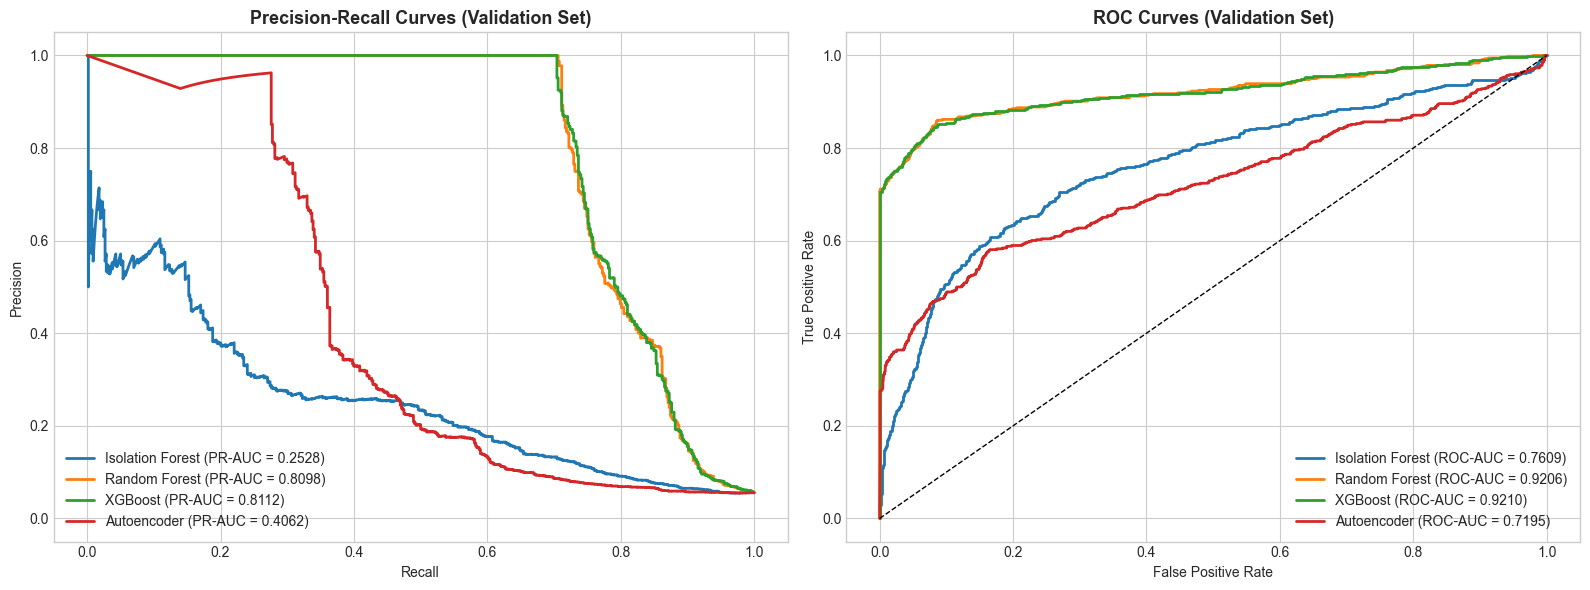

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR Curves
for name, prob in val_probs.items():
    prec, rec, _ = precision_recall_curve(y_val, prob)
    pr_auc = average_precision_score(y_val, prob)
    axes[0].plot(rec, prec, label=f"{name} (PR-AUC = {pr_auc:.4f})", lw=2)

axes[0].set_title("Precision-Recall Curves (Validation Set)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(loc="lower left")

# ROC Curves
for name, prob in val_probs.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    roc_auc = roc_auc_score(y_val, prob)
    axes[1].plot(fpr, tpr, label=f"{name} (ROC-AUC = {roc_auc:.4f})", lw=2)

axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curves (Validation Set)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()



## 4. Confusion Matrices (Validation Set)


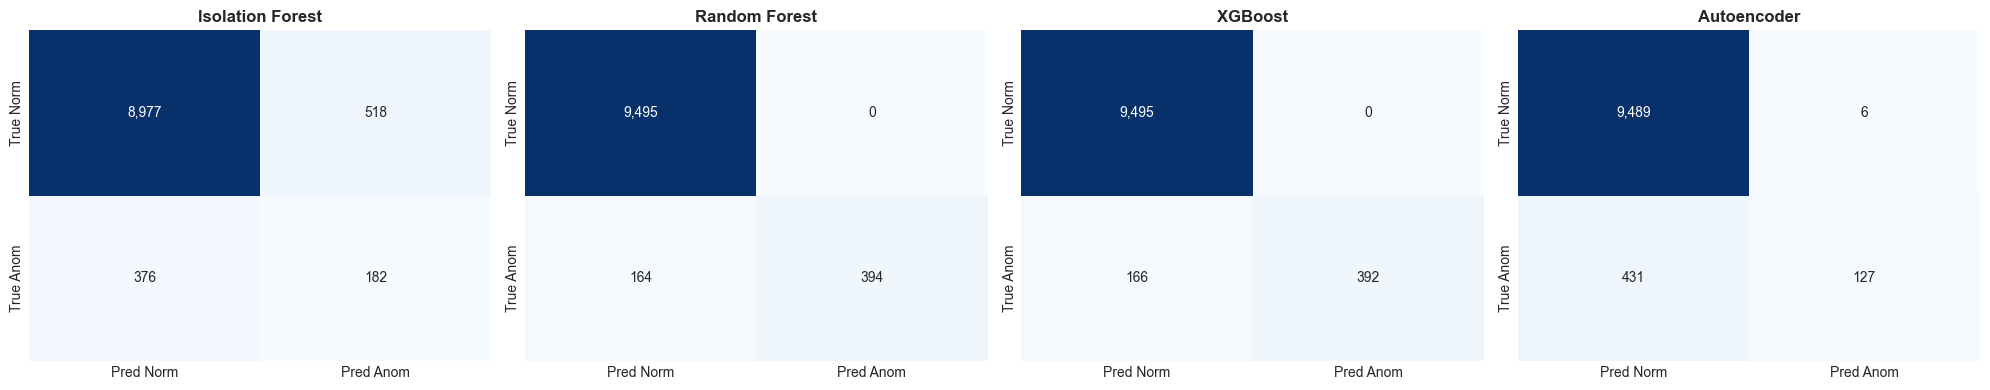

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, (name, pred) in enumerate(val_preds.items()):
    cm = confusion_matrix(y_val, pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=["Pred Norm", "Pred Anom"], yticklabels=["True Norm", "True Anom"])
    axes[idx].set_title(name, fontweight="bold")

plt.tight_layout()
plt.show()



## 5. Feature Importance Analysis (Random Forest & XGBoost)


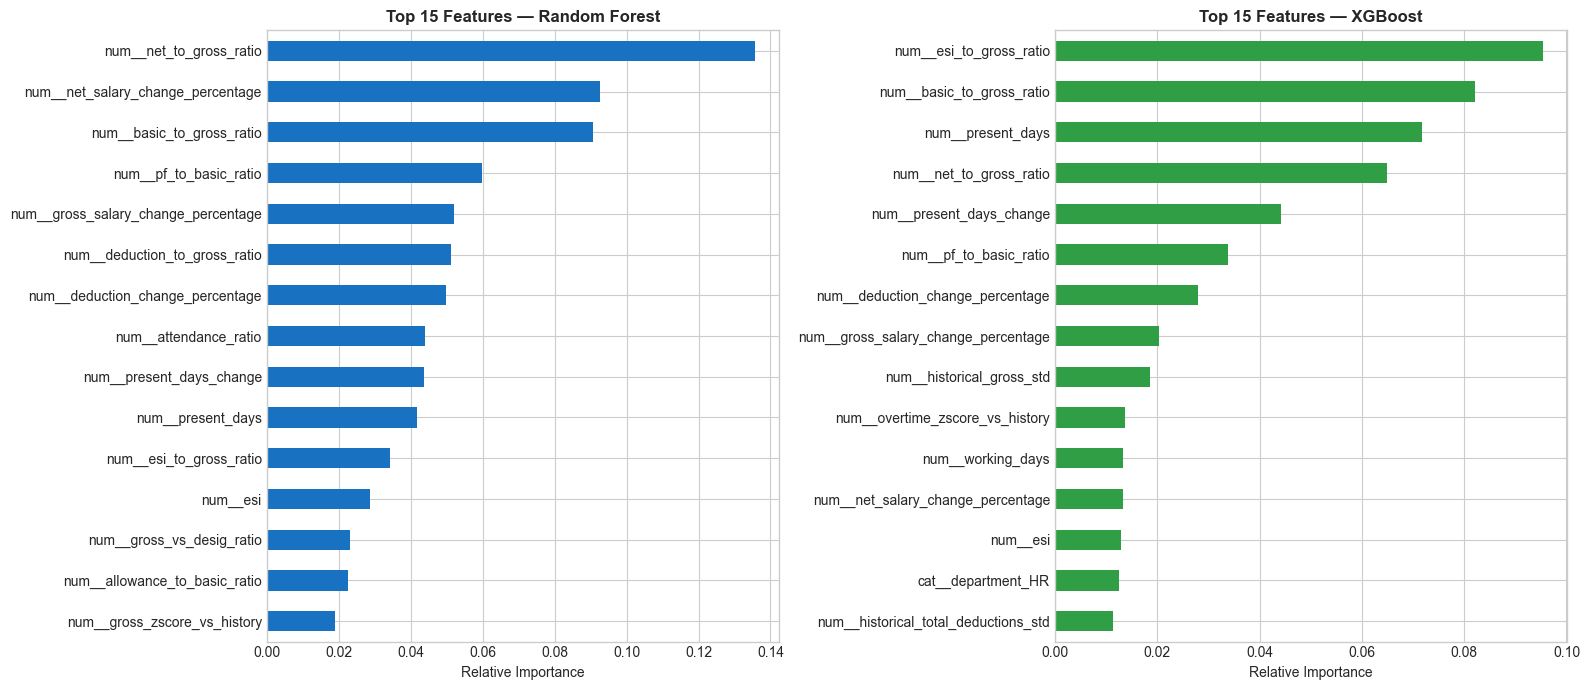

In [5]:
rf_importances = rf_model.get_feature_importances()
top_rf = pd.Series(rf_importances).head(15)

xgb_importances = xgb_model.get_feature_importances()
top_xgb = pd.Series(xgb_importances).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_rf.sort_values().plot(kind="barh", ax=axes[0], color="#1971c2")
axes[0].set_title("Top 15 Features — Random Forest", fontweight="bold")
axes[0].set_xlabel("Relative Importance")

top_xgb.sort_values().plot(kind="barh", ax=axes[1], color="#2f9e44")
axes[1].set_title("Top 15 Features — XGBoost", fontweight="bold")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()



## 6. Multi-Label Anomaly Type Classifier Performance


,support,detected,precision,recall,f1_score
SUDDEN_SALARY_INCREASE,120.0,120.0,1.0000,1.0000,1.0000
SUDDEN_SALARY_DECREASE,106.0,106.0,1.0000,1.0000,1.0000
EXCESSIVE_OVERTIME,106.0,106.0,1.0000,1.0000,1.0000
ATTENDANCE_PAY_MISMATCH,118.0,118.0,1.0000,1.0000,1.0000
IMPOSSIBLE_ATTENDANCE,111.0,110.0,1.0000,0.9910,0.9955
DUPLICATE_EMPLOYEE_RECORD,224.0,1640.0,0.0433,0.3170,0.0762
INCORRECT_PF,110.0,109.0,1.0000,0.9909,0.9954
INCORRECT_ESI,102.0,101.0,1.0000,0.9902,0.9951
ABNORMAL_DEDUCTION,108.0,108.0,1.0000,1.0000,1.0000
ABNORMALLY_HIGH_BONUS,114.0,116.0,0.9828,1.0000,0.9913


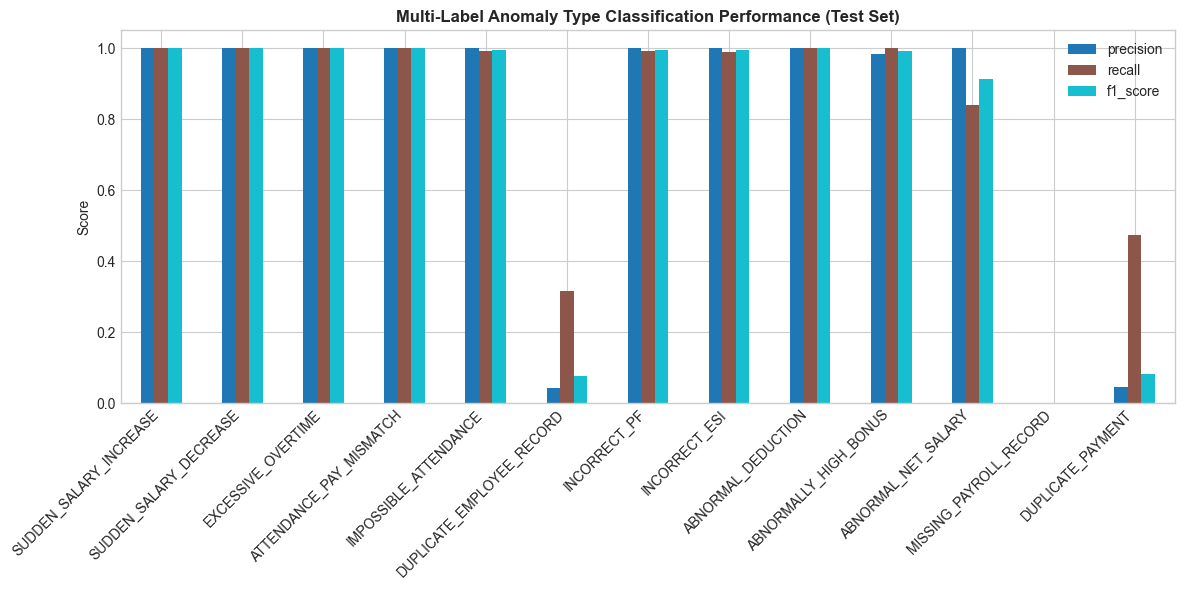

In [6]:
from ai.detection.type_classifier import MultiLabelAnomalyTypeClassifier

type_clf = MultiLabelAnomalyTypeClassifier.load(MODELS_DIR / "type_classifier.joblib")
type_results = type_clf.evaluate(X_test, meta_test["anomaly_type"], threshold=0.40)

type_df = pd.DataFrame(type_results["per_type_metrics"]).T
display(type_df)

fig, ax = plt.subplots(figsize=(12, 6))
type_df[["precision", "recall", "f1_score"]].plot(kind="bar", ax=ax, colormap="tab10")
plt.title("Multi-Label Anomaly Type Classification Performance (Test Set)", fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## 7. Error Analysis: False Positives & False Negatives


In [7]:
best_pred = rf_model.predict(X_test, threshold=rf_model.optimal_threshold)

fp_mask = (best_pred == 1) & (y_test.values == 0)
fn_mask = (best_pred == 0) & (y_test.values == 1)

print(f"Total False Positives on Test Set : {fp_mask.sum()} / {len(y_test):,} records")
print(f"Total False Negatives on Test Set : {fn_mask.sum()} / {len(y_test):,} records")

if fp_mask.sum() > 0:
    print("False Positive Records Sample:")
    display(meta_test[fp_mask].head(5))

if fn_mask.sum() > 0:
    print("False Negative Records Sample (Missed Anomaly Types):")
    display(meta_test[fn_mask]["anomaly_type"].value_counts().head(5))



Total False Positives on Test Set : 3 / 30,094 records
Total False Negatives on Test Set : 355 / 30,094 records
False Positive Records Sample:
False Negative Records Sample (Missed Anomaly Types):


,employee_id,payroll_month,joining_date,is_anomaly,anomaly_type
12986,EMP0004313,2024-10,2015-10-04,0,NONE
16905,EMP0005614,2024-10,2017-06-28,0,NONE
24963,EMP0008297,2024-10,2022-12-04,0,NONE


anomaly_type
DUPLICATE_EMPLOYEE_RECORD    188
DUPLICATE_PAYMENT            154
ABNORMAL_NET_SALARY           11
INCORRECT_ESI                  2

## 8. Final Model Selection & Unbiased Test Set Summary


In [8]:
import json

with open(MODELS_DIR / "model_config.json", "r") as f:
    config = json.load(f)

summary_df = pd.DataFrame([config])
display(summary_df.T.rename(columns={0: "Final Test Benchmark"}))



,Final Test Benchmark
selected_model,RandomForest
optimal_threshold,0.45
test_precision,0.9975
test_recall,0.7681
test_f1,0.8679
test_pr_auc,0.8484
test_roc_auc,0.9226
test_unique_emp_fp_per_1000,0.3
top_15_features,"[num__net_to_gross_ratio, num__net_salary_change_percentage, num__basic_to_gross_ratio, num__pf_to_basic_ratio, num__gross_salary_change_percentage, num__deduction_to_gross_ratio, num__deduction_change_percentage, num__attendance_ratio, num__present_days_change, num__present_days, num__esi_to_gross_ratio, num__esi, num__gross_vs_desig_ratio, num__allowance_to_basic_ratio, num__gross_zscore_vs_history]"
type_classifier_micro_f1,0.401
